## 👥 Customer Behavior & Revenue Analysis
This notebook analyzes customer ordering patterns and revenue contribution to identify high-value customers and demand distribution.

In [14]:
import pandas as pd

orders = pd.read_csv("../data/processed/clean_orders.csv")

### 📦 Customer Order Frequency
Analyzed how frequently customers place orders to understand engagement and retention patterns.

In [15]:
customer_summary = (
    orders.groupby('customer_id')
    .agg(
        total_orders=('order_id','count'),
        avg_order_value=('total','mean'),
        avg_rating=('rating','mean')
    )
    .reset_index()
)

customer_summary.head()

,customer_id,total_orders,avg_order_value,avg_rating
0,000285ae83ecf06a92b936d4f5b74342edb0e1940e1f00...,3,453.6000,5.0
1,00062fa202370fdd3076b794ec9358f36e35469bb8e5ff...,1,628.9500,NaN
2,001ab5fc3ee158b4d22e106897cee9b355e6eed50f163e...,1,1332.4000,NaN
3,001fdf2511dd137361424c9c15ea54774476691ceec5fa...,1,1352.4000,NaN
4,002afbd83626f0c699892fcb07b2ddf3858911482647b6...,4,805.6225,NaN


In [16]:
orders['rating'].isna().sum()

np.int64(18830)

In [17]:
orders['rating'].notna().sum()

np.int64(2491)

In [18]:
rated_orders = orders.dropna(subset=['rating'])

In [19]:
rated_orders.shape

(2491, 31)

In [20]:
rated_orders.groupby('rating')['order_id'].count()

rating
1.0     177
2.0      82
3.0     144
4.0     360
5.0    1728
Name: order_id, dtype: int64

In [21]:
customer_orders = (
    orders.groupby('customer_id')
    .agg(
        total_orders=('order_id','count'),
        avg_order_value=('total','mean')
    )
)

customer_ratings = (
    rated_orders.groupby('customer_id')
    .agg(
        avg_rating=('rating','mean'),
        ratings_given=('rating','count')
    )
)

customer_summary = customer_orders.merge(
    customer_ratings,
    on='customer_id',
    how='left'
).reset_index()

customer_summary.head()

,customer_id,total_orders,avg_order_value,avg_rating,ratings_given
0,000285ae83ecf06a92b936d4f5b74342edb0e1940e1f00...,3,453.6000,5.0,1.0
1,00062fa202370fdd3076b794ec9358f36e35469bb8e5ff...,1,628.9500,NaN,NaN
2,001ab5fc3ee158b4d22e106897cee9b355e6eed50f163e...,1,1332.4000,NaN,NaN
3,001fdf2511dd137361424c9c15ea54774476691ceec5fa...,1,1352.4000,NaN,NaN
4,002afbd83626f0c699892fcb07b2ddf3858911482647b6...,4,805.6225,NaN,NaN


In [22]:
customer_summary.to_csv("../data/processed/customer_summary.csv",index=False)

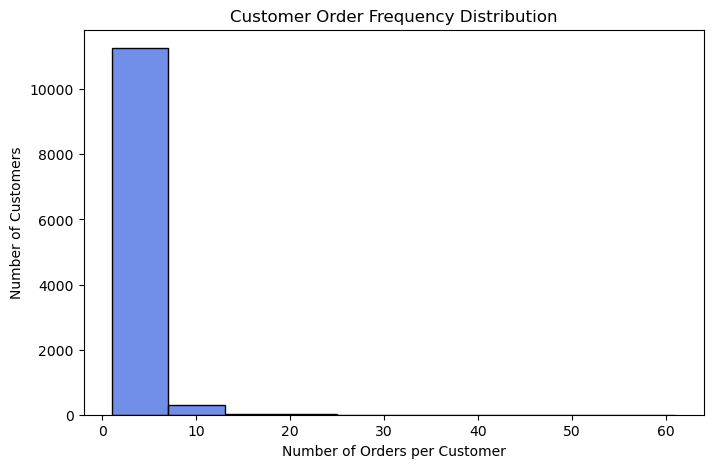

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    customer_summary['total_orders'],
    bins=10,
    color='royalblue'
)

plt.title("Customer Order Frequency Distribution")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")

plt.show()

### 💰 Revenue Concentration (Pareto Analysis)
Evaluated how revenue is distributed across customers to identify top contributors.

In [24]:
customer_revenue = (
    orders.groupby('customer_id')['total']
    .sum()
    .reset_index()
    .sort_values('total', ascending=False)
)

customer_revenue.head()

,customer_id,total
8899,c521ccf21e7bb2207c3f08d578b6e028d2c3b25986cb35...,28331.05
6351,8b5c4d6170343fbee92a6e577268b8aa8492105bdacbb8...,25207.83
825,12b07b9c3370baa5dd15fbfbc43c3dbc379fe66f73dbda...,22416.31
3607,4f0c8bb49d63ece05f5a6e04183b590b0add9efc83dbd4...,21355.94
8265,b64eade2d814bda0a3b16234e44400a4a9c0c44e5d6738...,20185.62


In [25]:
customer_revenue['cumulative_revenue'] = customer_revenue['total'].cumsum()
customer_revenue['cumulative_percent'] = (
    customer_revenue['cumulative_revenue'] /
    customer_revenue['total'].sum()
)

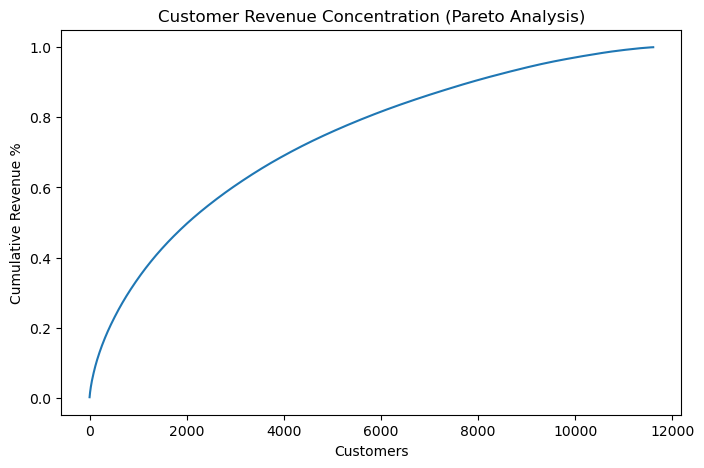

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    range(len(customer_revenue)),
    customer_revenue['cumulative_percent']
)

plt.xlabel("Customers")
plt.ylabel("Cumulative Revenue %")
plt.title("Customer Revenue Concentration (Pareto Analysis)")

plt.show()

### 💡 Key Insights

- 📉 **Most customers place very few orders**
  → Strong right-skewed distribution (majority < 5 orders)

- 🧍 **Small group of customers are highly active**
  → Long tail with some customers placing 20+ orders

- 💰 **Revenue is highly concentrated**
  → A small % of customers contribute a large share of total revenue

- 📊 **Clear Pareto behavior (80/20 pattern)**
  → Top customers drive disproportionate business value

### 🧠 Business Recommendations

- 🎯 Focus on retaining high-frequency customers (loyal users)  
- 💡 Introduce loyalty programs / rewards for repeat orders  
- 📢 Target low-frequency users with offers to increase engagement  
- 📦 Promote bundle deals to increase order frequency and value  